In [10]:
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

ROOT = Path.home() / "Documents" / "customer-churn-retention"
df = pd.read_csv(ROOT / "data" / "processed" / "features.csv")

# clustering (churn is NOT used)
df["contract_num"] = df["contract"].map({"Month-to-month": 0, "One year": 1, "Two year": 2})
seg_features = ["tenure_months", "monthly_charges", "total_charges", "num_addons", "contract_num"]
X = StandardScaler().fit_transform(df[seg_features])
df["segment"] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X)

# profile
profile = df.groupby("segment").agg(
    customers=("customer_id", "count"),
    avg_tenure=("tenure_months", "mean"),
    avg_monthly=("monthly_charges", "mean"),
    avg_addons=("num_addons", "mean"),
    pct_month_to_month=("contract_num", lambda s: (s == 0).mean()),
    pct_no_internet=("internet_service", lambda s: (s == "No").mean()),
    churn_rate=("churn_value", "mean"),
).round(2)
print(profile)

# names
names = {
    0: "Mid-tenure high-bill month-to-month",
    1: "Loyal high-value bundle",
    2: "New low-spend month-to-month",
    3: "Loyal phone-only low-bill",
}
df["segment_name"] = df["segment"].map(names)

# revenue at risk
df["churned_revenue"] = df["monthly_charges"] * df["churn_value"]
seg_value = df.groupby("segment_name").agg(
    customers=("customer_id", "count"),
    churn_rate=("churn_value", "mean"),
    monthly_revenue=("monthly_charges", "sum"),
    churned_monthly_revenue=("churned_revenue", "sum"),
).round(2)
seg_value["pct_revenue_lost"] = (seg_value["churned_monthly_revenue"] / seg_value["monthly_revenue"]).round(3)

# save
df.drop(columns="churned_revenue").to_csv(ROOT / "data" / "processed" / "features_segmented.csv", index=False)
profile.to_csv(ROOT / "reports" / "segment_profile.csv")
seg_value.to_csv(ROOT / "reports" / "segment_revenue_at_risk.csv")

seg_value.sort_values("churned_monthly_revenue", ascending=False)

         customers  avg_tenure  avg_monthly  avg_addons  pct_month_to_month  \
segment                                                                       
0             2115       25.70        81.70        2.58                0.82   
1             1743       61.67        90.84        4.25                0.11   
2             2106        8.13        46.28        0.53                0.93   
3             1079       45.44        25.50        0.34                0.00   

         pct_no_internet  churn_rate  
segment                               
0                   0.00        0.38  
1                   0.00        0.11  
2                   0.30        0.40  
3                   0.83        0.01  


,customers,churn_rate,monthly_revenue,churned_monthly_revenue,pct_revenue_lost
segment_name,,,,,
Mid-tenure high-bill month-to-month,2115,0.38,172792.9,71567.10,0.414
New low-spend month-to-month,2106,0.40,97469.0,47398.10,0.486
Loyal high-value bundle,1743,0.11,158336.1,19753.35,0.125
Loyal phone-only low-bill,1079,0.01,27518.6,412.30,0.015


In [11]:
print(df.columns.tolist())

['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents', 'city', 'state', 'phone_service', 'multiple_lines', 'internet_service', 'num_addons', 'tenure_months', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'cltv', 'churn_value', 'tenure_group', 'charge_per_service', 'mtm_echeck_flag', 'charge_vs_contract_avg', 'contract_num', 'segment', 'segment_name', 'churned_revenue']


In [12]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

ROOT = Path.home() / "Documents" / "customer-churn-retention"
df = pd.read_csv(ROOT / "data" / "processed" / "features.csv")

# features for clustering (churn is NOT used)
df["contract_num"] = df["contract"].map({"Month-to-month": 0, "One year": 1, "Two year": 2})
seg_features = ["tenure_months", "monthly_charges", "total_charges", "num_addons", "contract_num"]
X = StandardScaler().fit_transform(df[seg_features])

# clustering
km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X)
df["segment"] = km.labels_

# profile
profile = df.groupby("segment").agg(
    customers=("customer_id", "count"),
    avg_tenure=("tenure_months", "mean"),
    avg_monthly=("monthly_charges", "mean"),
    avg_addons=("num_addons", "mean"),
    pct_month_to_month=("contract_num", lambda s: (s == 0).mean()),
    pct_no_internet=("internet_service", lambda s: (s == "No").mean()),
    churn_rate=("churn_value", "mean"),
).round(2)
print(profile)

         customers  avg_tenure  avg_monthly  avg_addons  pct_month_to_month  \
segment                                                                       
0             2115       25.70        81.70        2.58                0.82   
1             1743       61.67        90.84        4.25                0.11   
2             2106        8.13        46.28        0.53                0.93   
3             1079       45.44        25.50        0.34                0.00   

         pct_no_internet  churn_rate  
segment                               
0                   0.00        0.38  
1                   0.00        0.11  
2                   0.30        0.40  
3                   0.83        0.01  


In [13]:
K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X)
df["segment"] = km.labels_

profile = df.groupby("segment").agg(
    customers=("customer_id", "count"),
    avg_tenure=("tenure_months", "mean"),
    avg_monthly=("monthly_charges", "mean"),
    avg_addons=("num_addons", "mean"),
    pct_month_to_month=("contract_num", lambda s: (s == 0).mean()),
    pct_no_internet=("internet_service", lambda s: (s == "No").mean()),
    churn_rate=("churn_value", "mean"),
).round(2)
profile

,customers,avg_tenure,avg_monthly,avg_addons,pct_month_to_month,pct_no_internet,churn_rate
segment,,,,,,,
0,2115,25.70,81.70,2.58,0.82,0.00,0.38
1,1743,61.67,90.84,4.25,0.11,0.00,0.11
2,2106,8.13,46.28,0.53,0.93,0.30,0.40
3,1079,45.44,25.50,0.34,0.00,0.83,0.01


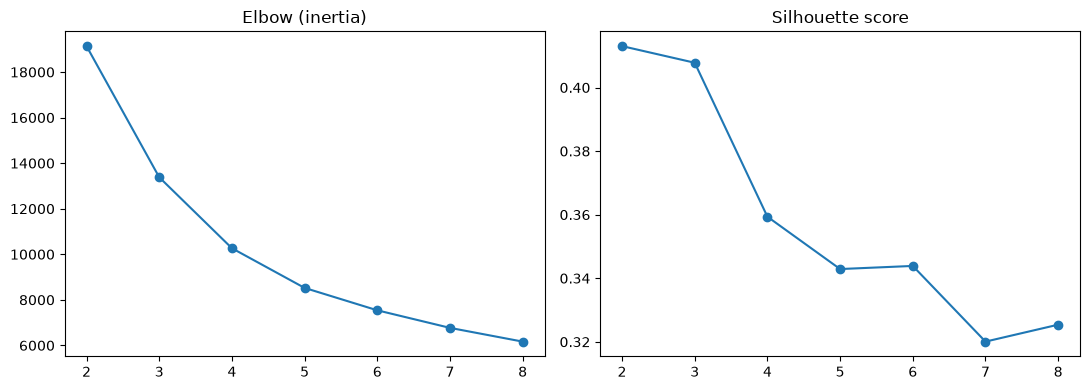

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ROOT = Path.home() / "Documents" / "customer-churn-retention"
df = pd.read_csv(ROOT / "data" / "processed" / "features.csv")

seg_features = ["tenure_months", "monthly_charges", "total_charges", "num_addons"]
df["contract_num"] = df["contract"].map({"Month-to-month": 0, "One year": 1, "Two year": 2})
seg_features.append("contract_num")

X = StandardScaler().fit_transform(df[seg_features])

# choose k: elbow + silhouette
inertias, sils = [], []
ks = range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ks, inertias, marker="o"); axes[0].set_title("Elbow (inertia)")
axes[1].plot(ks, sils, marker="o"); axes[1].set_title("Silhouette score")
plt.tight_layout()
plt.show()